# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
print("Hello World! We are learning deep learning.")


Hello World! We are learning deep learning.


In [2]:

import pandas as pd

customerData = pd.read_csv(r"C:\Users\tcetiner\PycharmProjects\CustomerChurnForecasting\data\customer-churn.csv")
customerData.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:

from sklearn.model_selection import train_test_split

churn = customerData["Churn"].map({"Yes": 1, "No": 0})
print(churn.head())

features = customerData.drop(["Churn", "customerID"], axis=1)


X_columns =features.columns
print("XXX")
print(X_columns)
features = pd.get_dummies(features,drop_first=True)
print(features.head())

X_train, X_test, y_train, y_test = train_test_split(features, churn, test_size=0.2)
print("Features printing")
features.head()
print(X_test.columns)



0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64
XXX
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')
   SeniorCitizen  tenure  MonthlyCharges  gender_Male  Partner_Yes  \
0              0       1           29.85        False         True   
1              0      34           56.95         True        False   
2              0       2           53.85         True        False   
3              0      45           42.30         True        False   
4              0       2           70.70        False        False   

   Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  \
0           False             False                            True   
1           Fa

In [4]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Printing values")
print(X_train)


Printing values
[[-0.43947526 -0.83076017 -1.48496154 ... -0.01332386 -0.01332386
  -0.01332386]
 [ 2.27544096  1.32647243  1.37543163 ... -0.01332386 -0.01332386
  -0.01332386]
 [-0.43947526  1.16366242  0.11525842 ... -0.01332386 -0.01332386
  -0.01332386]
 ...
 [-0.43947526 -1.27848769  0.50197824 ... -0.01332386 -0.01332386
  -0.01332386]
 [-0.43947526  1.40787743 -1.33160713 ... -0.01332386 -0.01332386
  -0.01332386]
 [ 2.27544096  1.04155492  1.14373312 ... -0.01332386 -0.01332386
  -0.01332386]]


In [5]:

from tensorflow import keras
from tensorflow.keras import layers





model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)


loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)
model.save("model.keras")


Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7142 - loss: 0.5509 - val_accuracy: 0.7480 - val_loss: 0.4961
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8897 - loss: 0.2603 - val_accuracy: 0.7533 - val_loss: 0.5041
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9643 - loss: 0.0989 - val_accuracy: 0.7338 - val_loss: 0.5495
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9816 - loss: 0.0501 - val_accuracy: 0.7276 - val_loss: 0.5712
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9809 - loss: 0.0387 - val_accuracy: 0.7196 - val_loss: 0.6157
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9827 - loss: 0.0330 - val_accuracy: 0.7223 - val_loss: 0.6264
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9834 - loss: 0.0308 - val_accuracy: 0.7205 - val_loss: 0.6437
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9847 - loss: 0.0284 - val_accuracy: 0.

In [6]:

import shap

X_sample = X_train[:20]

explainer = shap.KernelExplainer(model.predict, X_sample)
shap_values = explainer.shap_values(X_test[:20])


C:\Users\tcetiner\PycharmProjects\CustomerChurnForecasting\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


  5%|▌         | 1/20 [00:03<01:10,  3.69s/it]

...

 90%|█████████ | 18/20 [01:09<00:07,  3.86s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


 95%|█████████▌| 19/20 [01:13<00:03,  3.89s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


100%|██████████| 20/20 [01:16<00:00,  3.84s/it]


In [7]:


%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')


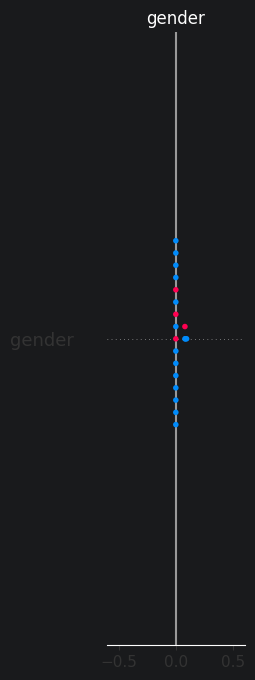

In [14]:

print(X_columns)
shap.summary_plot(
    shap_values,
    X_test[:20],
    feature_names=X_columns
)
